# Analyse van Mobiel Gebruikersgedrag

## Probleemdefinitie

Het gedrag van mobiele gebruikers – zoals schermtijd, appgebruik en batterijverbruik – wordt steeds belangrijker in onze digitale wereld. Deze gedragingen kunnen echter sterk verschillen afhankelijk van factoren zoals leeftijd, geslacht, het besturingssysteem en het type apparaat.

In dit project analyseren we deze gedragingen om gebruikers te groeperen op basis van gedrag, en om inzicht te krijgen in de kenmerken van elke groep.

---

## Doel van het Project

- Verschillende gebruikersgroepen definiëren (Hoog, Laag, enz.)
- Gedrag vergelijken op basis van leeftijd, geslacht en apparaatgegevens
- Patronen ontdekken tussen schermtijd, appgebruik en batterijverbruik
- Eventueel een voorspellend model bouwen voor gebruikersclassificatie
- Praktische inzichten leveren voor bedrijfsstrategieën

---

## Onderzoeksvragen

1. Hoe verschillen de klassen van gebruikersgedrag van elkaar?
2. Wat is de invloed van geslacht en leeftijdsgroep op het gedrag?
3. Welke correlaties bestaan er tussen schermtijd, appgebruik en batterijverbruik?
4. Is het mogelijk om de gedragsklasse van een gebruiker te voorspellen?


In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
#!pip install statsmodels
import statsmodels.stats.api as sms
#!pip install pyodbc
import warnings
from scipy.stats import ttest_1samp, shapiro, levene, ttest_ind, mannwhitneyu, \
    pearsonr, spearmanr, kendalltau, f_oneway, kruskal
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats
from scipy.stats import kstest
from scipy.stats import pearsonr

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', lambda x: '%.4f' % x)



In [2]:
file = os.getcwd()
filePath = 'GitHub_Projects\mobiel-gebruikersgedrag-en-statistische-analyse\dataset\user_behavior_dataset.csv'
df = pd.read_csv(filePath)

In [3]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4000,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7000,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0000,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8000,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3000,1367,58,988,31,Female,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User ID                     700 non-null    int64  
 1   Device Model                700 non-null    object 
 2   Operating System            700 non-null    object 
 3   App Usage Time (min/day)    700 non-null    int64  
 4   Screen On Time (hours/day)  700 non-null    float64
 5   Battery Drain (mAh/day)     700 non-null    int64  
 6   Number of Apps Installed    700 non-null    int64  
 7   Data Usage (MB/day)         700 non-null    int64  
 8   Age                         700 non-null    int64  
 9   Gender                      700 non-null    object 
 10  User Behavior Class         700 non-null    int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 60.3+ KB


In [5]:
df.isnull().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
                             ..
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
Length: 11, dtype: int64

In [6]:
df.shape

(700, 11)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User ID,700.0000,350.5000,202.2169,1.0000,175.7500,350.5000,525.2500,700.0000
App Usage Time (min/day),700.0000,271.1286,177.1995,30.0000,113.2500,227.5000,434.2500,598.0000
Screen On Time (hours/day),700.0000,5.2727,3.0686,1.0000,2.5000,4.9000,7.4000,12.0000
Battery Drain (mAh/day),700.0000,1525.1586,819.1364,302.0000,722.2500,1502.5000,2229.5000,2993.0000
Number of Apps Installed,700.0000,50.6814,26.9433,10.0000,26.0000,49.0000,74.0000,99.0000
Data Usage (MB/day),700.0000,929.7429,640.4517,102.0000,373.0000,823.5000,1341.0000,2497.0000
Age,700.0000,38.4829,12.0129,18.0000,28.0000,38.0000,49.0000,59.0000
User Behavior Class,700.0000,2.9900,1.4015,1.0000,2.0000,3.0000,4.0000,5.0000


In [8]:
df.columns

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')

In [9]:
df['Gedefineerde Behavior'] = df['User Behavior Class'].map({
    1: 'Zeer laag',
    2: 'Laag',
    3: 'Gemiddeld',
    4: 'Hoog',
    5: 'Zeer hoog'
}).astype('category') 

Waarom converteren naar categorische variabele?

De kolom ‘User Behavior Class’ bevat numerieke waarden (1 t/m 5), maar deze cijfers vertegenwoordigen gebruikerscategorieën, geen echte getallen. Daarom is het logisch om deze kolom als een ordinale categorische variabele te behandelen.

* Voordelen van het omzetten naar 'category' type:
Betere interpretatie in visualisaties
→ Grafieken zoals countplot of boxplot tonen categorieën duidelijker, in plaats van ze als getallen te behandelen.

Correcte verwerking in analyses
→ In groupby() wordt de kolom nu als een categorie behandeld, niet als een getal dat gemiddeld moet worden.

Verbeterde as-labels en volgorde
→ De X-as toont nu nette categorieën (1 t/m 5), eventueel zelfs met omschrijvingen zoals Laag – Hoog, in plaats van willekeurige getallen.

Efficiënter geheugenverbruik
→ category-types gebruiken minder geheugen dan int bij herhalende waarden.

Deze code vervangt de numerieke waarden (1 t/m 5) in de kolom User Behavior Class door beschrijvende labels.
Bijvoorbeeld: in plaats van alleen “1” te tonen, wordt het nu “Zeer laag”, wat veel duidelijker is.

 * Voordelen van deze aanpak:
Betere leesbaarheid
→ Grafieken en tabellen worden begrijpelijker voor de lezer of gebruiker van het dashboard.

Meer betekenisvolle visualisaties
→ In plaats van vage cijfers op de X-as krijg je duidelijke categorieën (zoals "Hoog", "Gemiddeld").

Professionelere rapportage
→ Als je resultaten presenteert in Power BI, Jupyter Notebook of een rapport, zorgen beschrijvende termen voor meer impact.

Makkelijker te interpreteren voor niet-technische gebruikers
→ Bijvoorbeeld marketeers of managers begrijpen sneller “Zeer hoog gedrag” dan “Klasse 5”.

In [10]:
# Eventueel kolomnamen iets leesbaarder maken 
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df

,user_id,device_model,operating_system,app_usage_time_(min/day),screen_on_time_(hours/day),battery_drain_(mah/day),number_of_apps_installed,data_usage_(mb/day),age,gender,user_behavior_class,gedefineerde_behavior
0,1,Google Pixel 5,Android,393,6.4000,1872,67,1122,40,Male,4,Hoog
1,2,OnePlus 9,Android,268,4.7000,1331,42,944,47,Female,3,Gemiddeld
2,3,Xiaomi Mi 11,Android,154,4.0000,761,32,322,42,Male,2,Laag
3,4,Google Pixel 5,Android,239,4.8000,1676,56,871,20,Male,3,Gemiddeld
4,5,iPhone 12,iOS,187,4.3000,1367,58,988,31,Female,3,Gemiddeld
...,...,...,...,...,...,...,...,...,...,...,...,...
695,696,iPhone 12,iOS,92,3.9000,1082,26,381,22,Male,2,Laag
696,697,Xiaomi Mi 11,Android,316,6.8000,1965,68,1201,59,Male,4,Hoog
697,698,Google Pixel 5,Android,99,3.1000,942,22,457,50,Female,2,Laag
698,699,Samsung Galaxy S21,Android,62,1.7000,431,13,224,44,Male,1,Zeer laag


In [11]:
# Categorieën in 'gender' bekijken
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

### Categorische variabelen

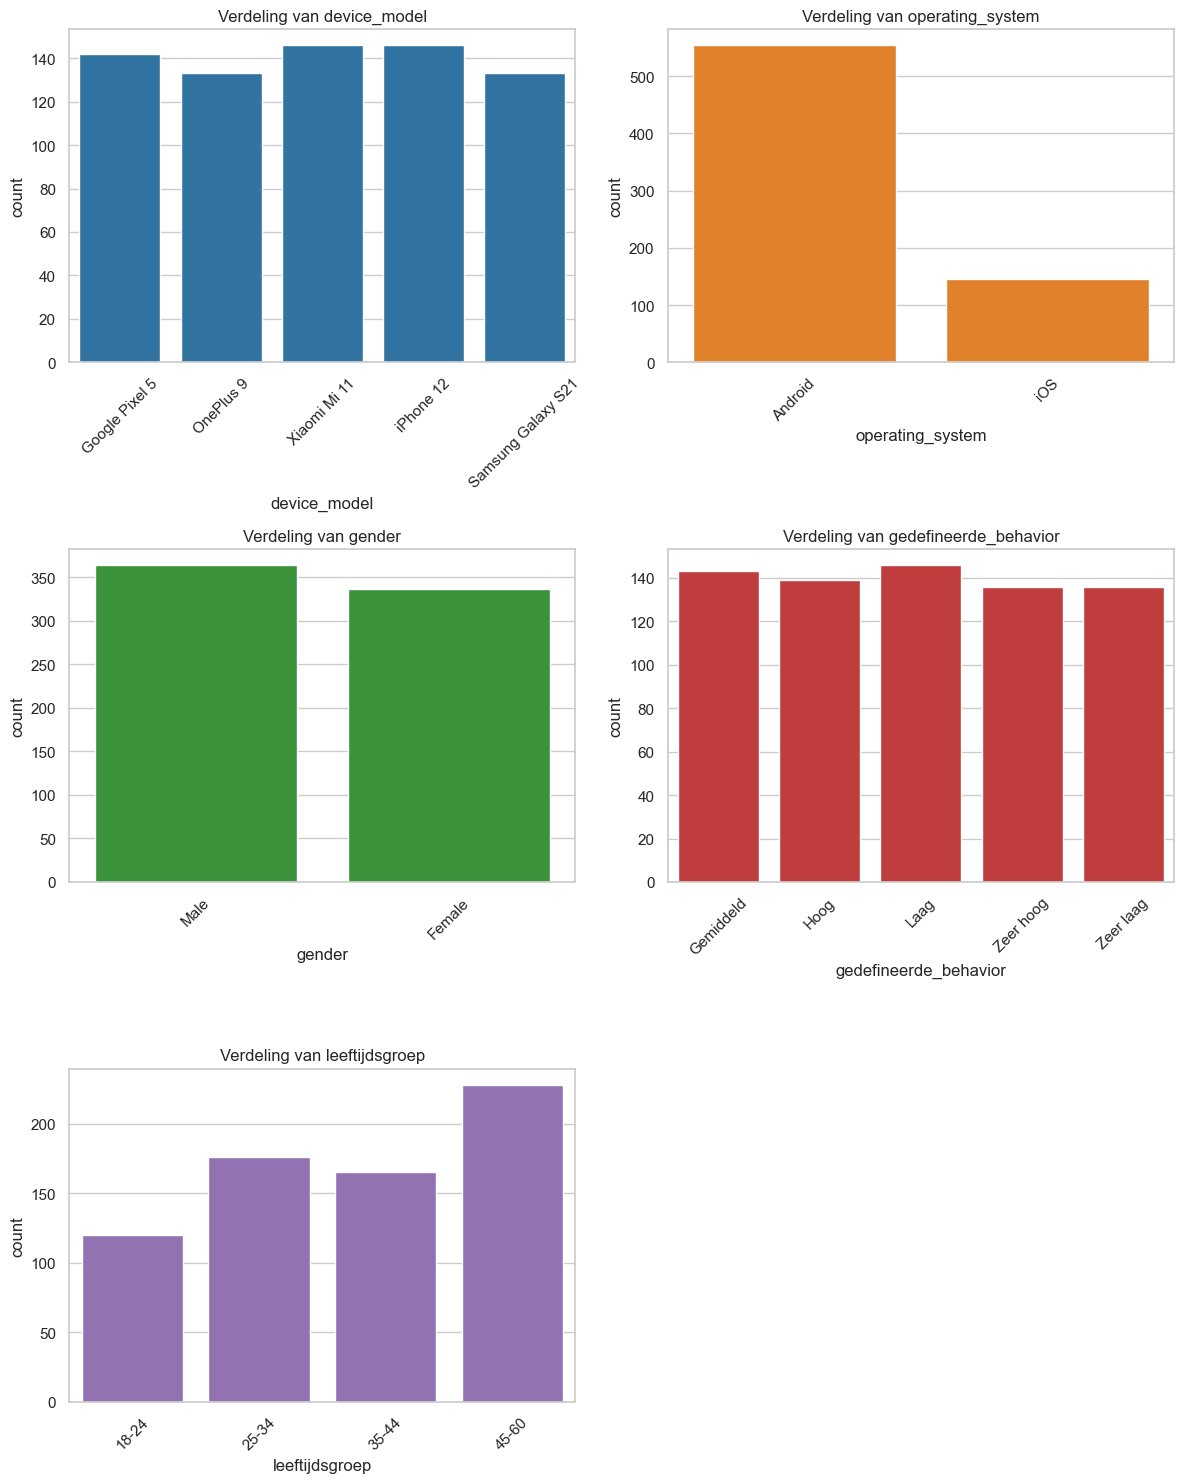

In [48]:
warnings.filterwarnings("ignore", category=FutureWarning)

# Categorische variabelen selecteren
kategorisch = df.select_dtypes(include=['object', 'category']).columns

# Kleurpalet genereren (her variabele krijgt een unieke kleur)
kleuren = sns.color_palette('tab10', n_colors=len(kategorisch))

# Instellingen voor subplots (her satırda 2 grafik olacak şekilde düzenledik)
cols = 2
rows = (len(kategorisch) + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
axes = axes.flatten()

for i, kolom in enumerate(kategorisch):
    sns.countplot(data=df, x=kolom, ax=axes[i], color=kleuren[i])  # unieke kleur per plot
    axes[i].set_title(f'Verdeling van {kolom}')
    axes[i].tick_params(axis='x', rotation=45)

# Eğer tek bir grafik kalırsa, boş ekseni sileriz
if len(kategorisch) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('categorische.png') 
plt.show()



### Frekwentie van apparaatsmodellen

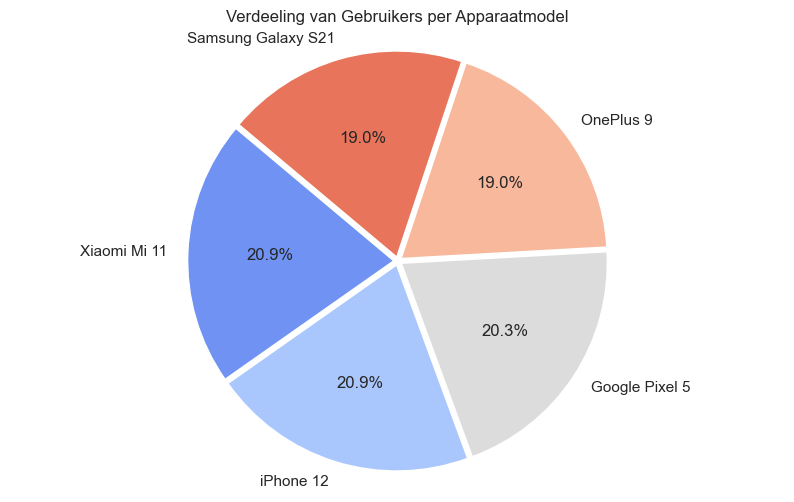

In [47]:

device_counts = df['device_model'].value_counts()


plt.figure(figsize=(10, 6))
plt.pie(device_counts, 
        labels=device_counts.index, 
        autopct='%1.1f%%',  # Percentage weergeven met 1 decimaal
        startangle=140,  # Beginhoek instellen
        colors=sns.color_palette('coolwarm', n_colors=len(device_counts)),  # Kleurenpalet
        explode=[0.02] * len(device_counts))  # Elke sectie iets naar buiten halen voor meer nadruk

# Titel en asseninstellingen
plt.title('Verdeeling van Gebruikers per Apparaatmodel')
plt.axis('equal')  # Zorg ervoor dat de taart cirkelvormig blijft
plt.savefig('frekwentie.png') 
plt.show()

##  KDE per apparaattype (Aantal geïnstalleerde apps)


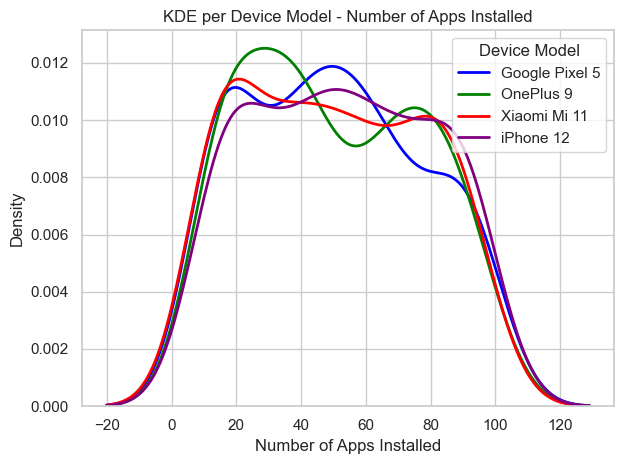

In [46]:
warnings.filterwarnings("ignore", category=FutureWarning)
sns.kdeplot(data=df[df["device_model"] == "Google Pixel 5"], x="number_of_apps_installed", label="Google Pixel 5", color="blue", linewidth=2)
sns.kdeplot(data=df[df["device_model"] == "OnePlus 9"], x="number_of_apps_installed", label="OnePlus 9", color="green", linewidth=2)
sns.kdeplot(data=df[df["device_model"] == "Xiaomi Mi 11"], x="number_of_apps_installed", label="Xiaomi Mi 11", color="red", linewidth=2)
sns.kdeplot(data=df[df["device_model"] == "iPhone 12"], x="number_of_apps_installed", label="iPhone 12", color="purple", linewidth=2)

# Titel en labels
plt.title("KDE per Device Model - Number of Apps Installed")
plt.xlabel("Number of Apps Installed")
plt.ylabel("Density")


plt.legend(title="Device Model", loc="upper right")

plt.tight_layout()
plt.savefig('kde_device.png') 
plt.show()

## Vraag 1: Demografische Analyse

Vraag: Hoe veranderen de mobiele gebruiksgewoonten op basis van leeftijd en geslacht?

 Doel van de analyse:

We onderzoeken hoe leeftijd en geslacht van invloed zijn op het appgebruik, schermtijd, batterijverbruik en dataverbruik. Dit helpt bij het ontdekken van gebruikspatronen onder verschillende demografische groepen.



### Stap 1: Verdeling van leeftijd en gebruiksvariabelen

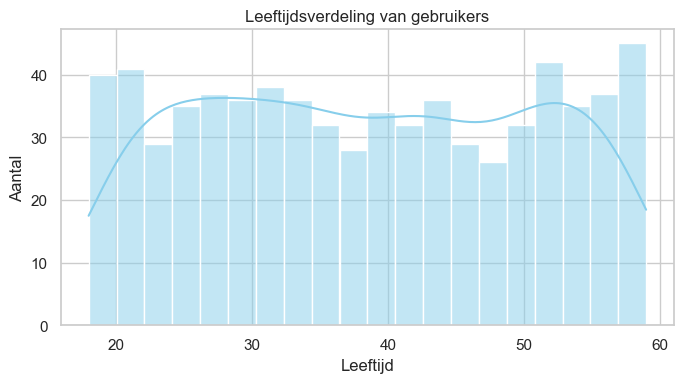

In [45]:
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set(style="whitegrid")
# Leeftijdsverdeling
plt.figure(figsize=(7, 4))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Leeftijdsverdeling van gebruikers')
plt.xlabel('Leeftijd')
plt.ylabel('Aantal')
plt.tight_layout()
plt.savefig('leeftijd.png') 
plt.show()


### Stap 2: Appgebruik t.o.v. leeftijd (lineaire relatie)

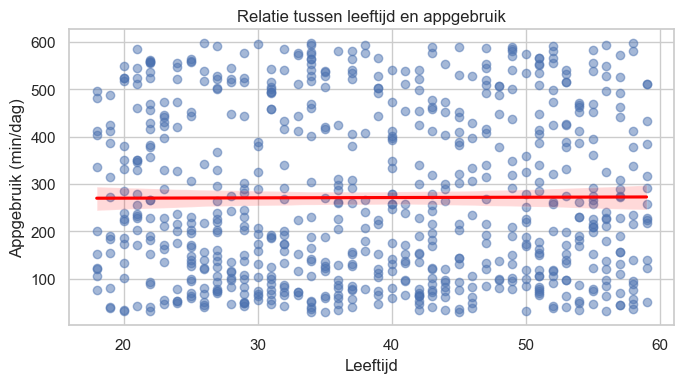

In [16]:
plt.figure(figsize=(7, 4))
sns.regplot(x='age', y='app_usage_time_(min/day)', data=df, scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})
plt.title('Relatie tussen leeftijd en appgebruik')
plt.xlabel('Leeftijd')
plt.ylabel('Appgebruik (min/dag)')
plt.tight_layout()
plt.show()

### Stap 3: Boxplots – Verschillen tussen mannen en vrouwen

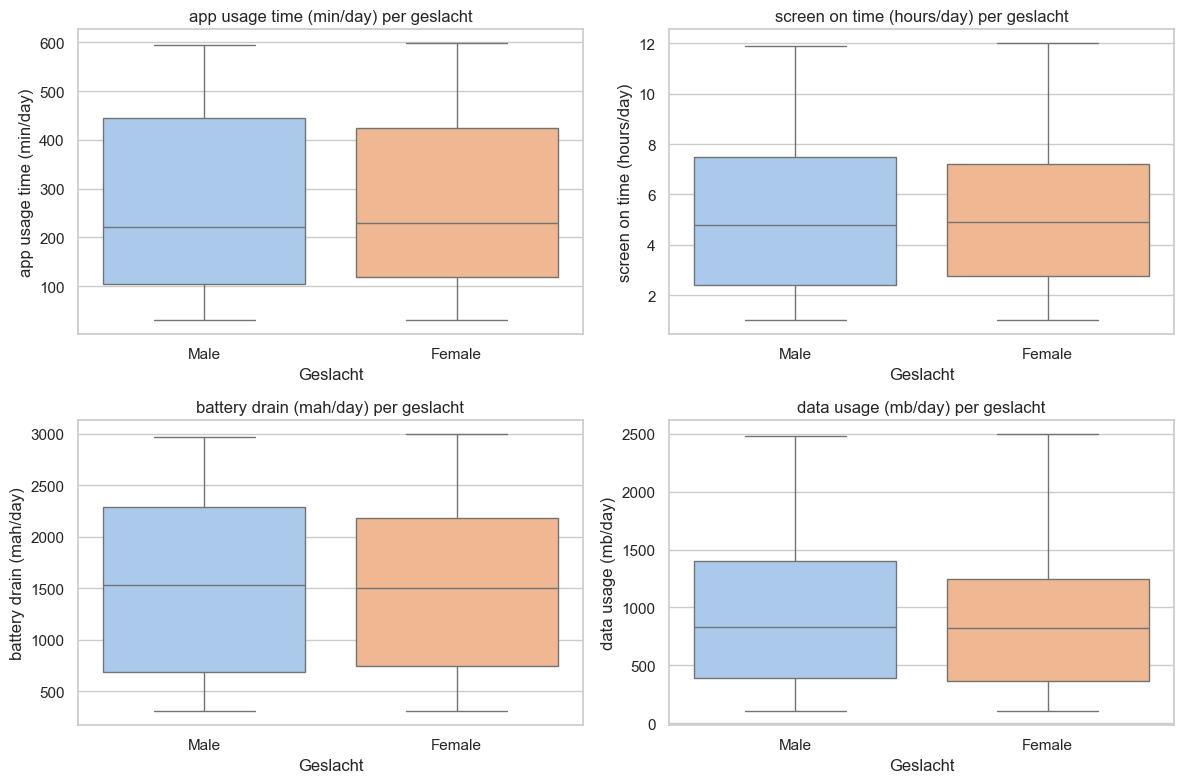

In [17]:
gebruik_variabelen = [
    'app_usage_time_(min/day)',
    'screen_on_time_(hours/day)',
    'battery_drain_(mah/day)',
    'data_usage_(mb/day)'
]

n = len(gebruik_variabelen)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, var in enumerate(gebruik_variabelen):
    sns.boxplot(x='gender', y=var, hue='gender', data=df, palette='pastel', ax=axes[i])
    axes[i].set_title(f'{var.replace("_", " ")} per geslacht')
    axes[i].set_xlabel('Geslacht')
    axes[i].set_ylabel(var.replace('_', ' '))

plt.tight_layout()
plt.show()


Interpretatie (Korte conclusie na visualisatie):

 “Uit de regressieplot blijkt dat jongere gebruikers gemiddeld meer tijd besteden aan apps. De boxplots laten zien dat er subtiele verschillen bestaan tussen mannen en vrouwen qua appgebruik, batterijverbruik en dataverbruik. Mannen tonen mogelijk hogere spreiding in schermtijd, terwijl vrouwen iets consistentere appgewoonten hebben.”

### STAP 4 - KDE Analyses (Kernel Density Estimation)

##  KDE per Geslacht

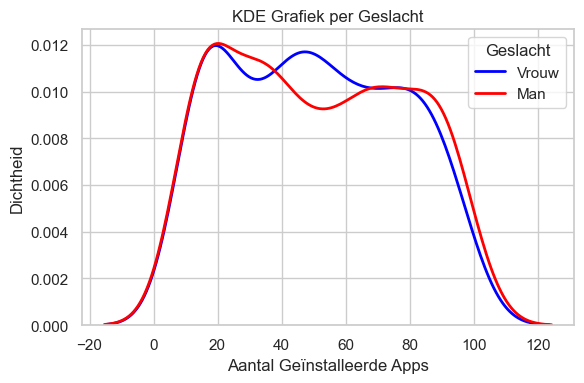

In [18]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(6, 4))
sns.kdeplot(
    data=df[df["gender"] == "Female"],
    x="number_of_apps_installed",
    label="Vrouw",
    color="blue",
    linewidth=2
)
sns.kdeplot(
    data=df[df["gender"] == "Male"],
    x="number_of_apps_installed",
    label="Man",
    color="red",
    linewidth=2
)

# Başlık ve eksenler
plt.title("KDE Grafiek per Geslacht")
plt.xlabel("Aantal Geïnstalleerde Apps")
plt.ylabel("Dichtheid")

# Legend (renk açıklaması)
plt.legend(title="Geslacht", loc="upper right")

plt.tight_layout()
plt.show()


##  KDE per Geslacht (Batterijverbruik)

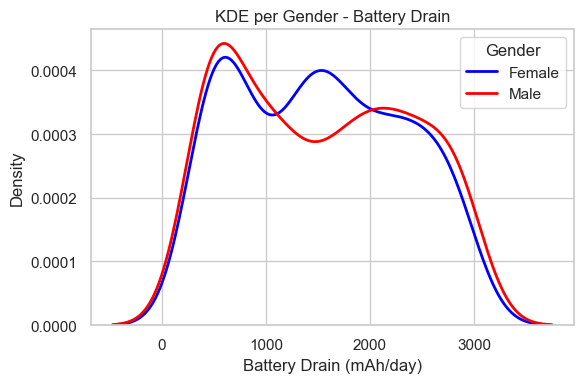

In [19]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(6, 4))
sns.kdeplot(data=df[df["gender"] == "Female"], x="battery_drain_(mah/day)", label="Female", color="blue", linewidth=2)
sns.kdeplot(data=df[df["gender"] == "Male"], x="battery_drain_(mah/day)", label="Male", color="red", linewidth=2)

# Başlık ve etiketler
plt.title("KDE per Gender - Battery Drain")
plt.xlabel("Battery Drain (mAh/day)")
plt.ylabel("Density")

# Legend (açıklama)
plt.legend(title="Gender", loc="upper right")

plt.tight_layout()
plt.show()

## KDE per Apparaatmodel

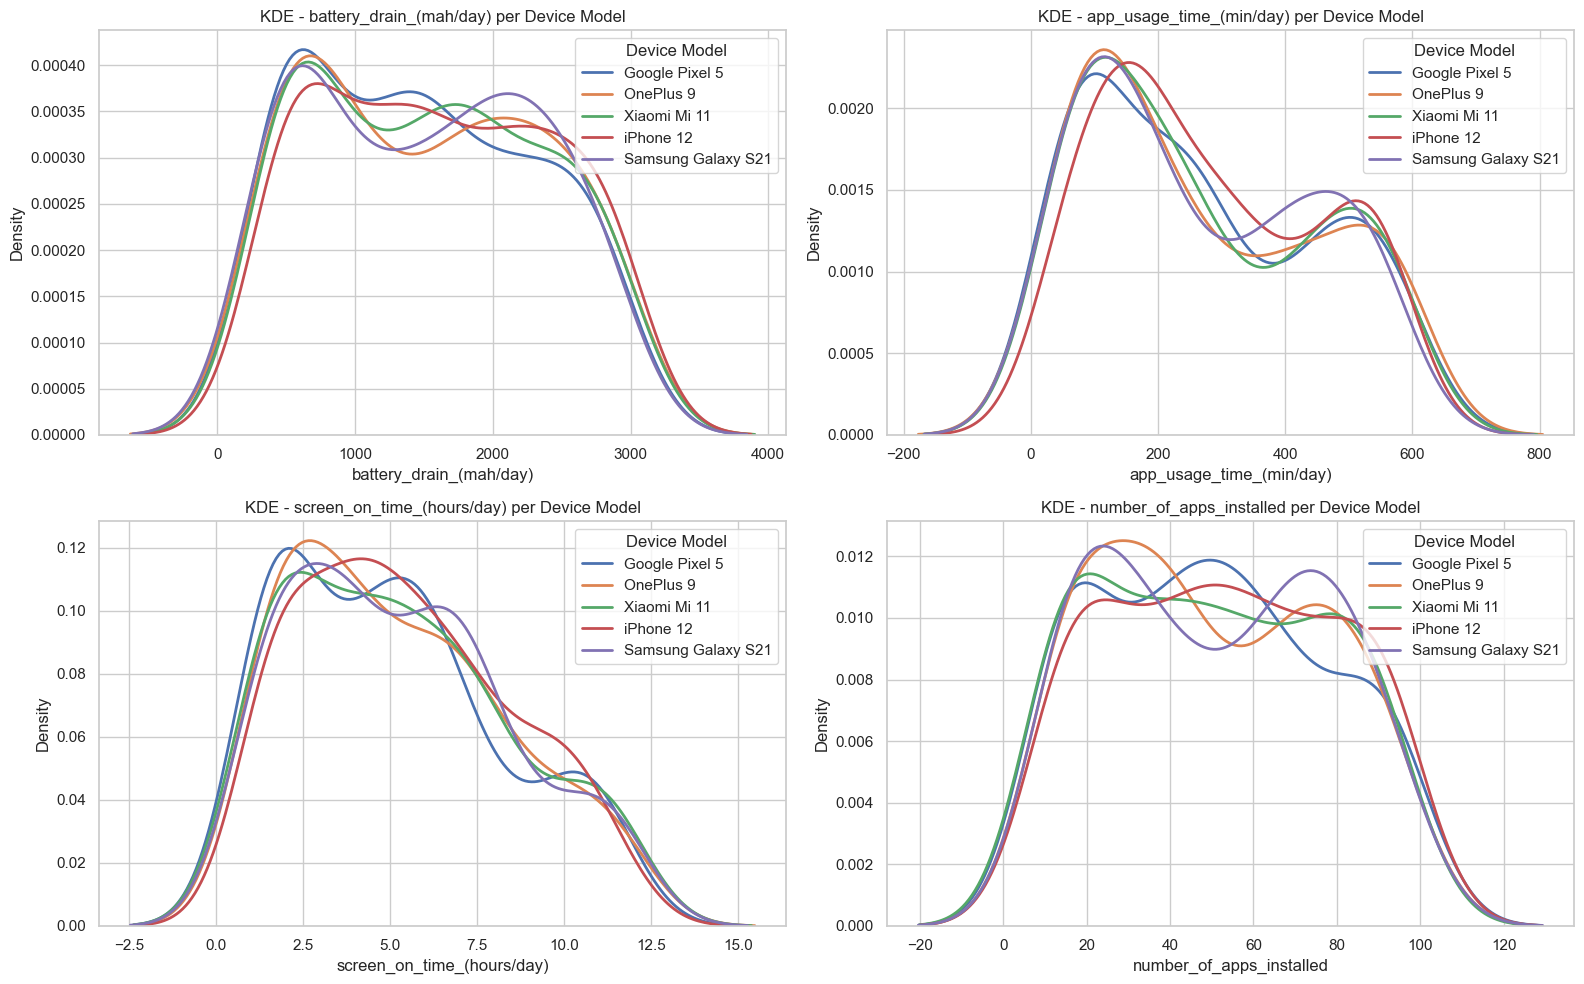

In [20]:
metrics = [
    "battery_drain_(mah/day)",
    "app_usage_time_(min/day)",
    "screen_on_time_(hours/day)",
    "number_of_apps_installed"
]

unique_devices = df["device_model"].unique()

num_columns = 2  # Her satırda 2 grafik
num_rows = (len(metrics) + num_columns - 1) // num_columns  # Satır sayısını hesapla

fig, axes = plt.subplots(num_rows, num_columns, figsize=(8 * num_columns, 5 * num_rows))

axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    for device in unique_devices:
        subset = df[df["device_model"] == device]
        if subset[metric].nunique() > 1:
            sns.kdeplot(
                data=subset,
                x=metric,
                label=device,
                linewidth=2,
                ax=ax
            )
    ax.set_title(f"KDE - {metric} per Device Model")
    ax.set_xlabel(metric)
    ax.set_ylabel("Density")
    ax.legend(title="Device Model", loc="upper right")


for j in range(len(metrics), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



## Vraag 1.1: Leeftijdsgroepen vs. Geslacht & Appgebruik
Vraag:
Is het verschil in appgebruik tussen mannen en vrouwen gelijk over alle leeftijdsgroepen?

 Doel van de analyse:
We bekijken of het verschil in appgebruik tussen mannen en vrouwen consistent blijft over verschillende leeftijdsgroepen. Dit doen we via:

Leeftijdsgroepen maken

Boxplots per groep

T-test voor statistisch verschil



### Stap 1: Leeftijdsgroepen definiëren

In [21]:
# Leeftijdsgroepen definiëren
leeftijd_bins = [18, 25, 35, 45, 60]  
leeftijd_labels = ['18-24', '25-34', '35-44', '45-60']
df['leeftijdsgroep'] = pd.cut(df['age'], bins=leeftijd_bins, labels=leeftijd_labels)

Deze code wordt gebruikt om de leeftijd (Age) variabele in verschillende leeftijdsgroepen te verdelen. Het groeperen van gebruikers in leeftijdscategorieën is nuttig voor demografische analyses en kan helpen om trends en patronen in het gebruik van technologie op basis van leeftijd te begrijpen. Dit zorgt ervoor dat je niet met een continue variabele werkt, maar met duidelijk gedefinieerde groepen, wat de analyse vereenvoudigt.

De pd.cut() functie maakt het mogelijk om een continue variabele, zoals leeftijd, in specifieke intervallen (bins) te verdelen en deze intervallen te labelen. Dit maakt de gegevens gemakkelijker te interpreteren en te visualiseren, vooral wanneer we demografische inzichten willen verkrijgen.

Voordelen van deze aanpak: Betere analyse: Door de leeftijd in groepen te verdelen, kun je trends per leeftijdsgroep analyseren in plaats van werken met een continue variabele. Eenvoudiger visualiseren: Het maakt het gemakkelijker om leeftijdsgroepen in grafieken te plotten (zoals staafdiagrammen), waardoor het resultaat duidelijker is. Vergelijkingen tussen groepen: Het helpt bij het vergelijken van gedragingen van verschillende leeftijdsgroepen, zoals het gebruik van apps, batterijverbruik, enzovoorts. Verhoogde efficiëntie: Dit type groepering maakt de analyses eenvoudiger en minder complex, wat leidt tot snellere inzichten en beslissingen.

### Informatie voor categorische gegevens

In [22]:

for col in ['gender', 'operating_system', 'user_behavior_class', 'leeftijdsgroep']:
    print(f"\n{col} values:\n", df[col].value_counts())


gender values:
 gender
Male      364
Female    336
Name: count, dtype: int64

operating_system values:
 operating_system
Android    554
iOS        146
Name: count, dtype: int64

user_behavior_class values:
 user_behavior_class
2    146
3    143
4    139
5    136
1    136
Name: count, dtype: int64

leeftijdsgroep values:
 leeftijdsgroep
45-60    228
25-34    176
35-44    165
18-24    120
Name: count, dtype: int64


## KDE per Age Group - App Usage Time

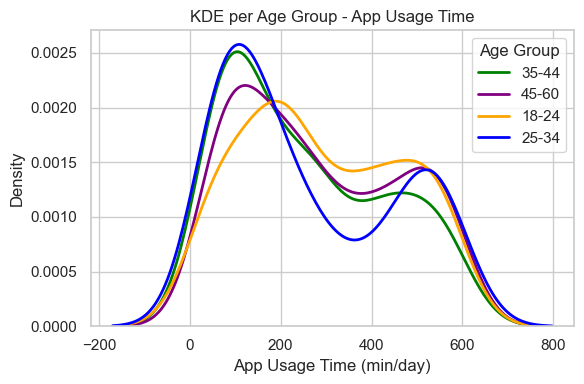

In [44]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(6, 4))
sns.kdeplot(data=df[df["leeftijdsgroep"] == "35-44"], x="app_usage_time_(min/day)", label="35-44", color="green", linewidth=2)
sns.kdeplot(data=df[df["leeftijdsgroep"] == "45-60"], x="app_usage_time_(min/day)", label="45-60", color="purple", linewidth=2)
sns.kdeplot(data=df[df["leeftijdsgroep"] == "18-24"], x="app_usage_time_(min/day)", label="18-24", color="orange", linewidth=2)
sns.kdeplot(data=df[df["leeftijdsgroep"] == "25-34"], x="app_usage_time_(min/day)", label="25-34", color="blue", linewidth=2)

plt.title("KDE per Age Group - App Usage Time")
plt.xlabel("App Usage Time (min/day)")
plt.ylabel("Density")

plt.legend(title="Age Group", loc="upper right")

plt.tight_layout()
plt.savefig('kde_age_appUsage.png') 
plt.show()

### Stap 2: Boxplot – Appgebruik per leeftijdsgroep & geslacht

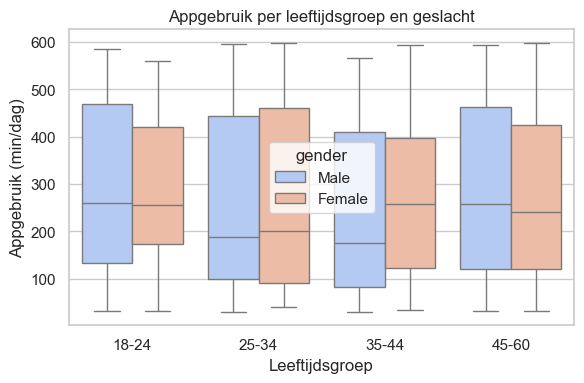

In [24]:
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(6, 4))
sns.boxplot(x='leeftijdsgroep', y='app_usage_time_(min/day)', hue='gender', data=df, palette='coolwarm')
plt.title('Appgebruik per leeftijdsgroep en geslacht')
plt.xlabel('Leeftijdsgroep')
plt.ylabel('Appgebruik (min/dag)')
plt.tight_layout()
plt.show()

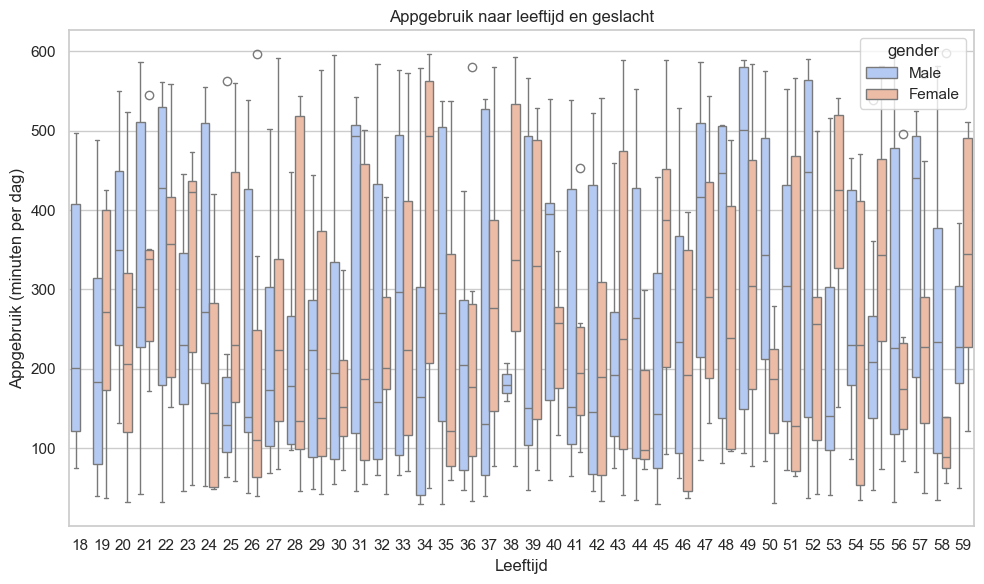

In [25]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='age', y='app_usage_time_(min/day)', hue='gender', data=df, palette='coolwarm')
plt.title('Appgebruik naar leeftijd en geslacht')
plt.xlabel('Leeftijd')
plt.ylabel('Appgebruik (minuten per dag)')
plt.tight_layout()
plt.savefig('leeftijd_gender_vs_appgebruik.png', dpi=300)
plt.show()


### Stap 3: Statistische toets – T-test per leeftijdsgroep

In [26]:
# Resultaten opslaan
resultaten = []

for groep in leeftijd_labels:
    subgroep = df[df['leeftijdsgroep'] == groep]
    mannen = subgroep[subgroep['gender'] == 'Male']['app_usage_time_(min/day)']
    vrouwen = subgroep[subgroep['gender'] == 'Female']['app_usage_time_(min/day)']
    
    if len(mannen) > 1 and len(vrouwen) > 1:
        t_stat, p_val = ttest_ind(mannen, vrouwen, equal_var=False)
        resultaten.append({
            'Leeftijdsgroep': groep,
            'T-waarde': round(t_stat, 3),
            'P-waarde': round(p_val, 4)
        })
    else:
        resultaten.append({
            'Leeftijdsgroep': groep,
            'T-waarde': None,
            'P-waarde': None
        })

# DataFrame tonen
resultaten_df = pd.DataFrame(resultaten)
print(resultaten_df)


  Leeftijdsgroep  T-waarde  P-waarde
0          18-24    0.1060    0.9160
1          25-34   -0.4050    0.6862
2          35-44   -1.0070    0.3156
3          45-60    0.8410    0.4012


p < 0.05 → significant verschil tussen man & vrouw in die leeftijdsgroep

p ≥ 0.05 → geen significant verschil

Resultaten van de t-toets per leeftijdsgroep

Leeftijdsgroep t-waarde p-waarde Interpretatie 18-24 0.1060 0.9160 Geen significant verschil 25-34 -0.4050 0.6862 Geen significant verschil 35-44 -1.0070 0.3156 Geen significant verschil 45-60 0.8410 0.4012 Geen significant verschil

Conclusie:
Er is geen statistisch significant verschil in appgebruik tussen mannen en vrouwen binnen elke leeftijdsgroep.

🔹 De p-waarden zijn allemaal boven de 0.05, wat betekent dat we de nulhypothese (dat er geen verschil is) niet kunnen verwerpen.

🔹 Het gebruiksgedrag van mannen en vrouwen is dus vergelijkbaar, ongeacht de leeftijdscategorie.

Implicatie voor dit project:

Dit resultaat suggereert dat geslacht geen doorslaggevende factor is in het dagelijkse appgebruik binnen verschillende leeftijdsgroepen. Dit kan belangrijk zijn voor gebruikerssegmentatie, marketingstrategieën of productaanpassing: je hoeft mogelijk niet te differentiëren op basis van geslacht als het gaat om gebruiksduur.

## Vraag 2: Verschillen in appgebruik op basis van besturingssysteem

Vraag:
Is er een verschil in app-gebruikstijden tussen gebruikers van verschillende besturingssystemen (Android vs iOS)?

 Doel van de analyse:
We willen weten of Android- en iOS-gebruikers hun apps op verschillende manieren gebruiken qua duur per dag. Hiervoor:

Maken we een boxplot per besturingssysteem

Gebruiken we een t-test om het verschil te testen



### Stap 1: Boxplot – Appgebruik per OS

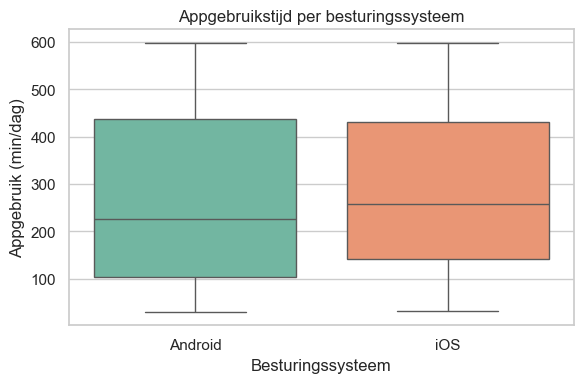

In [27]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='operating_system', y='app_usage_time_(min/day)', hue = 'operating_system', data=df, palette='Set2')
plt.title('Appgebruikstijd per besturingssysteem')
plt.xlabel('Besturingssysteem')
plt.ylabel('Appgebruik (min/dag)')
plt.tight_layout()
plt.show()


 ### Stap 2: T-test – Android vs iOS

In [28]:

android_usage = df[df['operating_system'] == 'Android']['app_usage_time_(min/day)']
ios_usage = df[df['operating_system'] == 'iOS']['app_usage_time_(min/day)']

# T-test uitvoeren
t_stat, p_value = stats.ttest_ind(android_usage, ios_usage, equal_var=False)


print(f"T-waarde: {t_stat:.3f}")
print(f"P-waarde: {p_value:.4f}")


if p_value < 0.05:
    print("Er is een significant verschil in appgebruik tussen Android- en iOS-gebruikers.")
else:
    print("Er is geen significant verschil in appgebruik tussen Android- en iOS-gebruikers.")


T-waarde: -0.862
P-waarde: 0.3896
Er is geen significant verschil in appgebruik tussen Android- en iOS-gebruikers.


Wat betekent dit?

P-waarde > 0.05

→ Dit betekent dat het verschil in gemiddelde appgebruikstijd tussen Android- en iOS-gebruikers niet statistisch significant is.

T-waarde negatief
    
→ De gemiddelde gebruikstijd is iets lager bij Android-gebruikers dan bij iOS-gebruikers, maar dit verschil is klein en niet betekenisvol.

Conclusie:

 Op basis van onze data kunnen we niet concluderen dat gebruikers van Android of iOS hun apps duidelijk meer of minder gebruiken dan de andere groep.

 Mogelijke oorzaken:

De verdeling van gebruikers tussen Android en iOS is misschien niet gelijk.

Er kunnen andere factoren zijn (zoals leeftijd, gedragstype) die appgebruik beïnvloeden.

### Analyse 3: Relatie tussen aantal geïnstalleerde apps en dagelijks gegevensgebruik

Doel van de analyse

Onderzoeken of gebruikers die meer apps geïnstalleerd hebben, ook meer mobiele data verbruiken.

Hypothese: Meer apps → meer kans op achtergrondactiviteit → hoger dataverbruik.



###  Stap 1 – Visualisatie maken (scatterplot)

### Visualisatie: Aantal apps vs. Dataverbruik

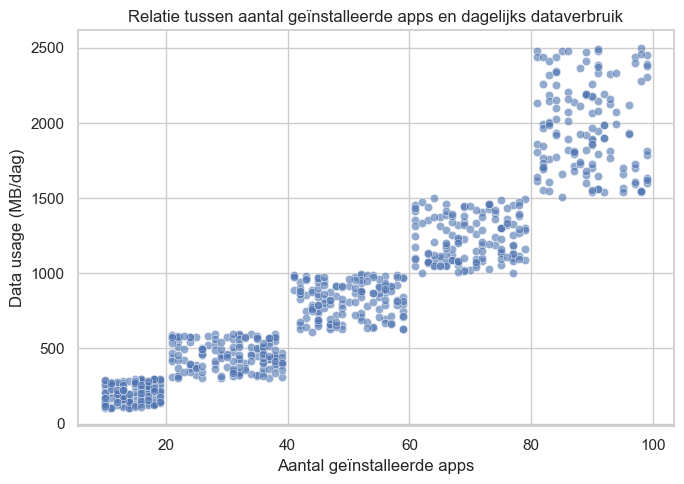

In [29]:

plt.figure(figsize=(7, 5))
sns.scatterplot(x='number_of_apps_installed', y='data_usage_(mb/day)', data=df, alpha=0.6)
plt.title('Relatie tussen aantal geïnstalleerde apps en dagelijks dataverbruik')
plt.xlabel('Aantal geïnstalleerde apps')
plt.ylabel('Data usage (MB/dag)')
plt.tight_layout()
plt.show()


### Stap 2 – Correlatie analyse (Pearson)

De Pearson correlatie test wordt gebruikt om de lineaire relatie tussen twee continue variabelen te testen. Deze test helpt ons te begrijpen hoe sterk twee variabelen samen veranderen.

Bijvoorbeeld, als we willen weten of er een relatie is tussen het aantal geïnstalleerde apps en het dagelijks data gebruik, gebruiken we de Pearson correlatie test.

Nulhypothese: "Er is geen relatie tussen de twee variabelen" (de correlatiecoëfficiënt is 0).

Alternatieve hypothese: "Er is een significant verband tussen de twee variabelen" (de correlatiecoëfficiënt is niet gelijk aan 0).

De Pearson test meet de sterkte van de lineaire relatie tussen twee continue variabelen. De correlatiecoëfficiënt geeft aan hoe sterk de relatie is en of deze positief of negatief is.

Waarom Pearson Correlatie Test?

De t-test wordt gebruikt om het verschil tussen twee groepen te testen, maar we willen hier de relatie tussen twee continue variabelen onderzoeken. Dus, we willen weten of er een lineaire relatie is tussen het aantal geïnstalleerde apps en dagelijks data gebruik.

De Pearson correlatie test is geschikt voor het testen van deze relatie tussen twee continue variabelen

Als we het verschil tussen twee groepen willen testen, gebruiken we de t-test (bijvoorbeeld, het verschil tussen Android- en iOS-gebruikers).

Als we de relatie tussen twee continue variabelen willen testen, gebruiken we de Pearson correlatie test (bijvoorbeeld, de relatie tussen het aantal geïnstalleerde apps en dagelijks data gebruik).

In [30]:

corr, p_value = pearsonr(df['number_of_apps_installed'], df['data_usage_(mb/day)'])


print(f' Pearson Correlatiecoëfficiënt: {corr:.3f}')
print(f' P-waarde: {p_value:.4f}')


if p_value < 0.05:
    print("De correlatie is significant – er is een verband tussen het aantal apps en dataverbruik.")
else:
    print("De correlatie is niet significant – geen duidelijk verband tussen het aantal apps en dataverbruik.")


 Pearson Correlatiecoëfficiënt: 0.935
 P-waarde: 0.0000
De correlatie is significant – er is een verband tussen het aantal apps en dataverbruik.


  Interpretatie:

Sterke positieve correlatie: De Pearson-correlatiecoëfficiënt van 0.935 toont een zeer sterke positieve relatie aan. Dit betekent dat hoe meer apps een gebruiker installeert, hoe hoger het dagelijks dataverbruik.

P-waarde: 0.0000: De p-waarde is erg laag, wat de relatie statistisch significant maakt (meestal geldt een p-waarde kleiner dan 0.05 als significant). Dit betekent dat er een echte relatie is tussen het aantal geïnstalleerde apps en het dataverbruik.

  Conclusie:

Er is een sterke en significante relatie. Hoe meer apps gebruikers installeren, hoe meer data ze verbruiken. Dit kan te maken hebben met achtergrondactiviteiten van apps zoals synchronisatie, updates en gegevensverkeer, die het dataverbruik verhogen. Dit resultaat laat zien dat het aantal geïnstalleerde apps een belangrijke factor is in het dataverbruik.

## Vraag 4. Schermtijd en Batterijverbruik: 

Is er een relatie tussen de schermtijd en het batterijverbruik?
Deze analyse onderzoekt of er een verband is tussen de dagelijkse schermtijd (schermtijd) en het batterijverbruik (batterijverbruik). Dit type relatie kan ons helpen de efficiëntie van mobiele apparaten beter te begrijpen. Bijvoorbeeld, we kunnen bekijken of langere schermtijd resulteert in sneller batterijverbruik.



### Stap 1: Gegevensvoorbereiding en Visualisatie

De eerste stap is om een scatter plot (verspreidingsdiagram) te maken om de relatie tussen schermtijd en batterijverbruik te visualiseren.

### Schermtijd en batterijverbruik visualiseren

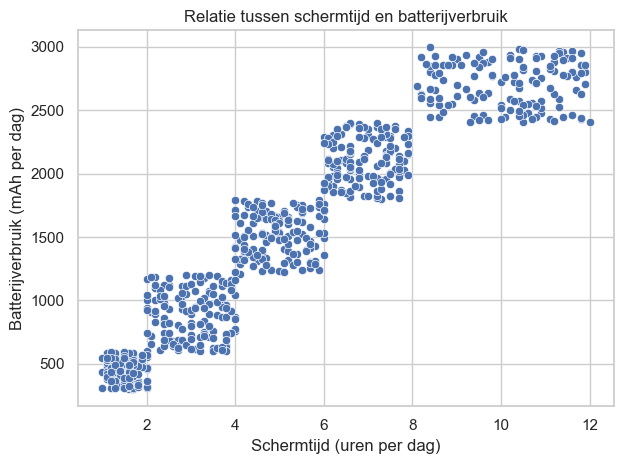

In [31]:

sns.scatterplot(x='screen_on_time_(hours/day)', y='battery_drain_(mah/day)', data=df)
plt.title('Relatie tussen schermtijd en batterijverbruik')
plt.xlabel('Schermtijd (uren per dag)')
plt.ylabel('Batterijverbruik (mAh per dag)')
plt.tight_layout()
plt.show()


In deze grafiek is de horizontale as de dagelijkse schermtijd (schermtijd) en de verticale as het dagelijkse batterijverbruik (batterijverbruik). Elk punt in de grafiek vertegenwoordigt het gebruik van een gebruiker, met hun schermtijd en batterijverbruik.

### Stap 2: Berekening van de Pearson Correlatie

Vervolgens berekenen we de Pearson correlatiecoëfficiënt om de relatie tussen schermtijd en batterijverbruik nauwkeuriger te meten. Deze coëfficiënt meet de lineaire relatie tussen twee variabelen.

In [32]:
screen_time = df['screen_on_time_(hours/day)']
battery_usage = df['battery_drain_(mah/day)']


pearson_corr, p_value = pearsonr(screen_time, battery_usage)


print(f'Pearson Correlatie Coëfficiënt: {pearson_corr}')
print(f'P-waarde: {p_value}')


Pearson Correlatie Coëfficiënt: 0.9489831361266117
P-waarde: 0.0


Interpretatie:

Pearson Correlatie Coëfficiënt (0.9489): De waarde is bijna 1, wat wijst op een zeer sterke positieve correlatie tussen schermtijd (screen-on time) en batterijverbruik. Dit betekent dat naarmate de schermtijd toeneemt, het batterijverbruik ook toeneemt. Er lijkt dus een duidelijke en sterke relatie te zijn tussen deze twee variabelen.

P-waarde (0.0): De p-waarde is 0.0, wat betekent dat de bevinding statistisch significant is (onder de gebruikelijke drempel van 0.05). Dit suggereert dat de relatie tussen schermtijd en batterijverbruik geen toeval is en dat er een betrouwbare correlatie bestaat.

Conclusie:

Er is een sterke en statistisch significante relatie tussen de schermtijd en het batterijverbruik. Gebruikers die meer tijd op hun mobiele apparaten doorbrengen, verbruiken aanzienlijk meer batterij. Dit benadrukt het belang van schermtijd bij het beheren van batterijverbruik op mobiele apparaten, en het kan helpen bij het optimaliseren van batterijbeheer of het ontwerpen van energiezuinigere apparaten.

Praktische Implicatie: De inzichten kunnen nuttig zijn voor fabrikanten van mobiele apparaten, die mogelijk energie-efficiëntere schermen en batterijbeheersystemen kunnen ontwikkelen om het energieverbruik van apparaten met veel schermtijd te optimaliseren.

In samenvatting: 

Het is evident dat de hoeveelheid tijd die gebruikers hun apparaten gebruiken sterk bijdraagt aan het batterijverbruik, en dit zou in overweging moeten worden genomen bij zowel het ontwerp als het gebruik van mobiele technologieën.

## Vraag 5: Gedragssegmentatie

Vraag: Welke gedragscategorieën (user_behavior_class) vertonen het hoogste appgebruik of batterijverbruik?

    Doel van de analyse

We willen begrijpen hoe verschillende gedragsklassen (bijvoorbeeld 'Heavy Users', 'Moderate Users', enz.) zich onderscheiden op basis van hun appgebruik, batterijverbruik, schermtijd en dataverbruik.
Dit helpt bij het creëren van gebruikersprofielen of persona’s voor marketing, productontwikkeling of gebruikerservaring.



### Stap 1: Visualiseer het appgebruik per gedragscategorie

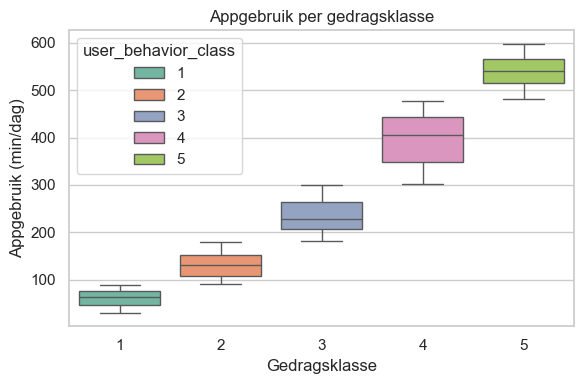

In [33]:
sns.set(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.boxplot(x='user_behavior_class', y='app_usage_time_(min/day)', hue = 'user_behavior_class', data=df, palette='Set2')
plt.title('Appgebruik per gedragsklasse')
plt.xlabel('Gedragsklasse')
plt.ylabel('Appgebruik (min/dag)')
plt.tight_layout()
plt.show()


### Stap 2: Batteryverbruik per gedragscategorie

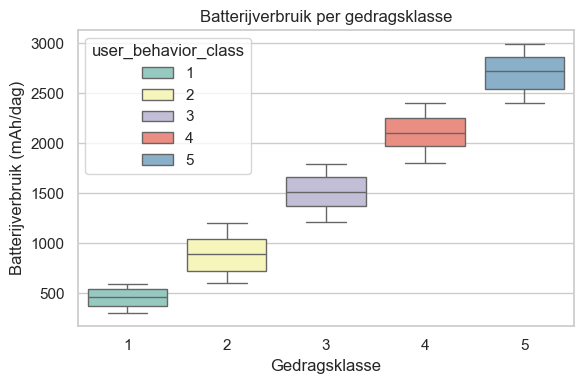

In [34]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='user_behavior_class', y='battery_drain_(mah/day)', hue = 'user_behavior_class', data=df, palette='Set3')
plt.title('Batterijverbruik per gedragsklasse')
plt.xlabel('Gedragsklasse')
plt.ylabel('Batterijverbruik (mAh/dag)')
plt.tight_layout()
plt.show()


### Stap 3: Schermtijd en dataverbruik per gedragsklasse

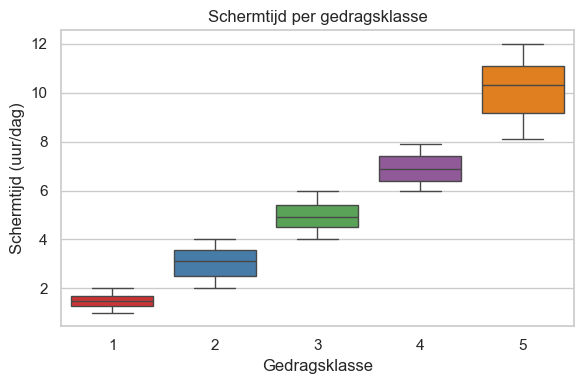

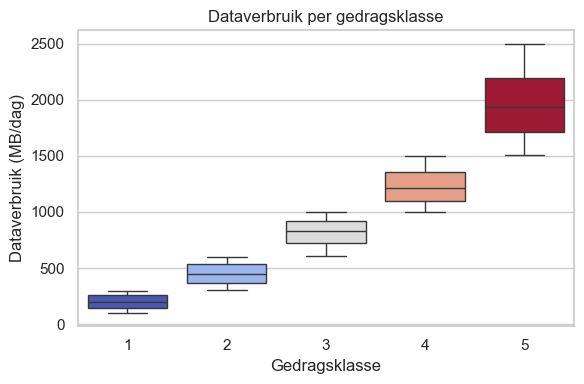

In [35]:

# Grafik 1: Schermtijd per gedragsklasse
plt.figure(figsize=(6, 4))
sns.boxplot(
    x='user_behavior_class',
    y='screen_on_time_(hours/day)',
    hue='user_behavior_class',
    data=df,
    palette='Set1'
)
plt.title('Schermtijd per gedragsklasse')
plt.xlabel('Gedragsklasse')
plt.ylabel('Schermtijd (uur/dag)')
plt.legend().remove()
plt.tight_layout()
plt.show()

# Grafik 2: Dataverbruik per gedragsklasse
plt.figure(figsize=(6, 4))
sns.boxplot(
    x='user_behavior_class',
    y='data_usage_(mb/day)',
    hue='user_behavior_class',
    data=df,
    palette='coolwarm'
)
plt.title('Dataverbruik per gedragsklasse')
plt.xlabel('Gedragsklasse')
plt.ylabel('Dataverbruik (MB/dag)')
plt.legend().remove()
plt.tight_layout()
plt.show()



Na het bekijken van deze grafieken kun je bijvoorbeeld zeggen:

  “De ‘Heavy Users’ hebben duidelijk het hoogste appgebruik en batterijverbruik, terwijl ‘Light Users’ minder intensief gebruik tonen. Dit bevestigt dat de gedragsklassen goed de gebruiksintensiteit weergeven. Opvallend is ook dat sommige matige gebruikers relatief hoge schermtijden hebben, wat kan wijzen op passief gebruik.”

## Vraag 6- Efficiëntie-analyse:

Vraag: Welke gebruikersgroep heeft de hoogste 'efficiëntie' qua appgebruik vs batterijverbruik?

Nieuwe Metriek creëren:

We gaan een nieuwe metriek creëren, genaamd efficiëntie. Deze metriek is de verhouding tussen de app_usage_time (tijd die aan apps wordt besteed) en battery_drain (de dagelijkse batterijverbruik).

Formule:

efficiente = app_usage_time / battery_drain
 
Nieuwe kolom toevoegen:

We voegen nu een nieuwe kolom toe aan de dataframe die de efficiëntie voor elke gebruiker bevat.

Waarom deze analyse belangrijk is voor "power users" detectie en apparaat efficiëntie:

Voordelen en waarom we het moeten doen:

Efficiëntiemeting:

Door een efficiëntie-metriek te creëren die de relatie meet tussen app-gebruikstijd en batterijverbruik (app_usage_time / battery_drain), kunnen we het efficiënte gebruik van apparaten vaststellen. Dit is vooral nuttig voor gebruikers die energie-efficiëntie willen optimaliseren en voor apparaatfabrikanten die de prestaties van hun producten willen verbeteren.

Detectie van Power Users:

Met deze metriek kunnen we "power users" identificeren, oftewel gebruikers die veel apps gebruiken maar een relatief laag batterijverbruik hebben. Deze gebruikers vertonen vaak optimaal gebruiksgedrag en de informatie die we verkrijgen, kan waardevol zijn voor apparaatontwerp en energiebeheerstrategieën.

Leeftijd, Geslacht, Besturingssysteem en Gebruikersgedrag:

Hoe verandert de efficiëntie tussen verschillende gebruikersgroepen? Deze analyse helpt ons de verschillen te zien op basis van leeftijdsgroepen, geslacht, besturingssysteem (Android/iOS) en gebruikersgedrag (user behavior class). Bijv. sommige groepen kunnen het batterijverbruik efficiënter beheren, terwijl andere groepen meer energie verbruiken.

App-optimalisatie en Energie-efficiëntie:

Deze analyse kan helpen bij het ontwikkelen van energie-efficiëntie en app-optimalisatiestrategieën. Energie-efficiënte gebruikers kunnen bewust zijn van hun app-gebruik om de batterijduur te verlengen. Tegelijkertijd kunnen voor minder energie-efficiënte gebruikers aanbevelingen voor batterijbesparing of software-updates worden gegeven.

Stappen:

De efficiëntie-metriek wordt gecreëerd: efficiëntie = app_usage_time / battery_drain

Voor elke groep (gender, leeftijdsgroep, besturingssysteem, gebruikersgedrag) worden boxplots gemaakt.

Deze boxplots helpen ons te visualiseren welke groepen efficiënter zijn.

Resultaat:

Ja, deze analyse zal waardevolle inzichten bieden over de efficiëntie. De verkregen gegevens kunnen nuttig zijn voor apparaatfabrikanten, softwareontwikkelaars en gebruikers. Daarnaast biedt de detectie van "power users" de mogelijkheid om diepgaande analyses te maken over apparaatoptimalisatie en batterij-efficiëntie.



#### Nieuwe efficiëntie kolom creëren

In [36]:
df['efficiëntie'] = df['app_usage_time_(min/day)'] / df['battery_drain_(mah/day)']
df['efficiëntie'].mean()

0.16824747000164983

Nu hebben we een nieuwe kolom genaamd efficiëntie.

Efficiëntie visualiseren per verschillende groepen:
We gaan de efficiëntie visualiseren op basis van verschillende demografische kenmerken, zoals gender, leeftijdsgroep, besturingssysteem en gedrag klasse. We zullen hiervoor boxplots gebruiken.

Boxplot voor verschillende groepen:

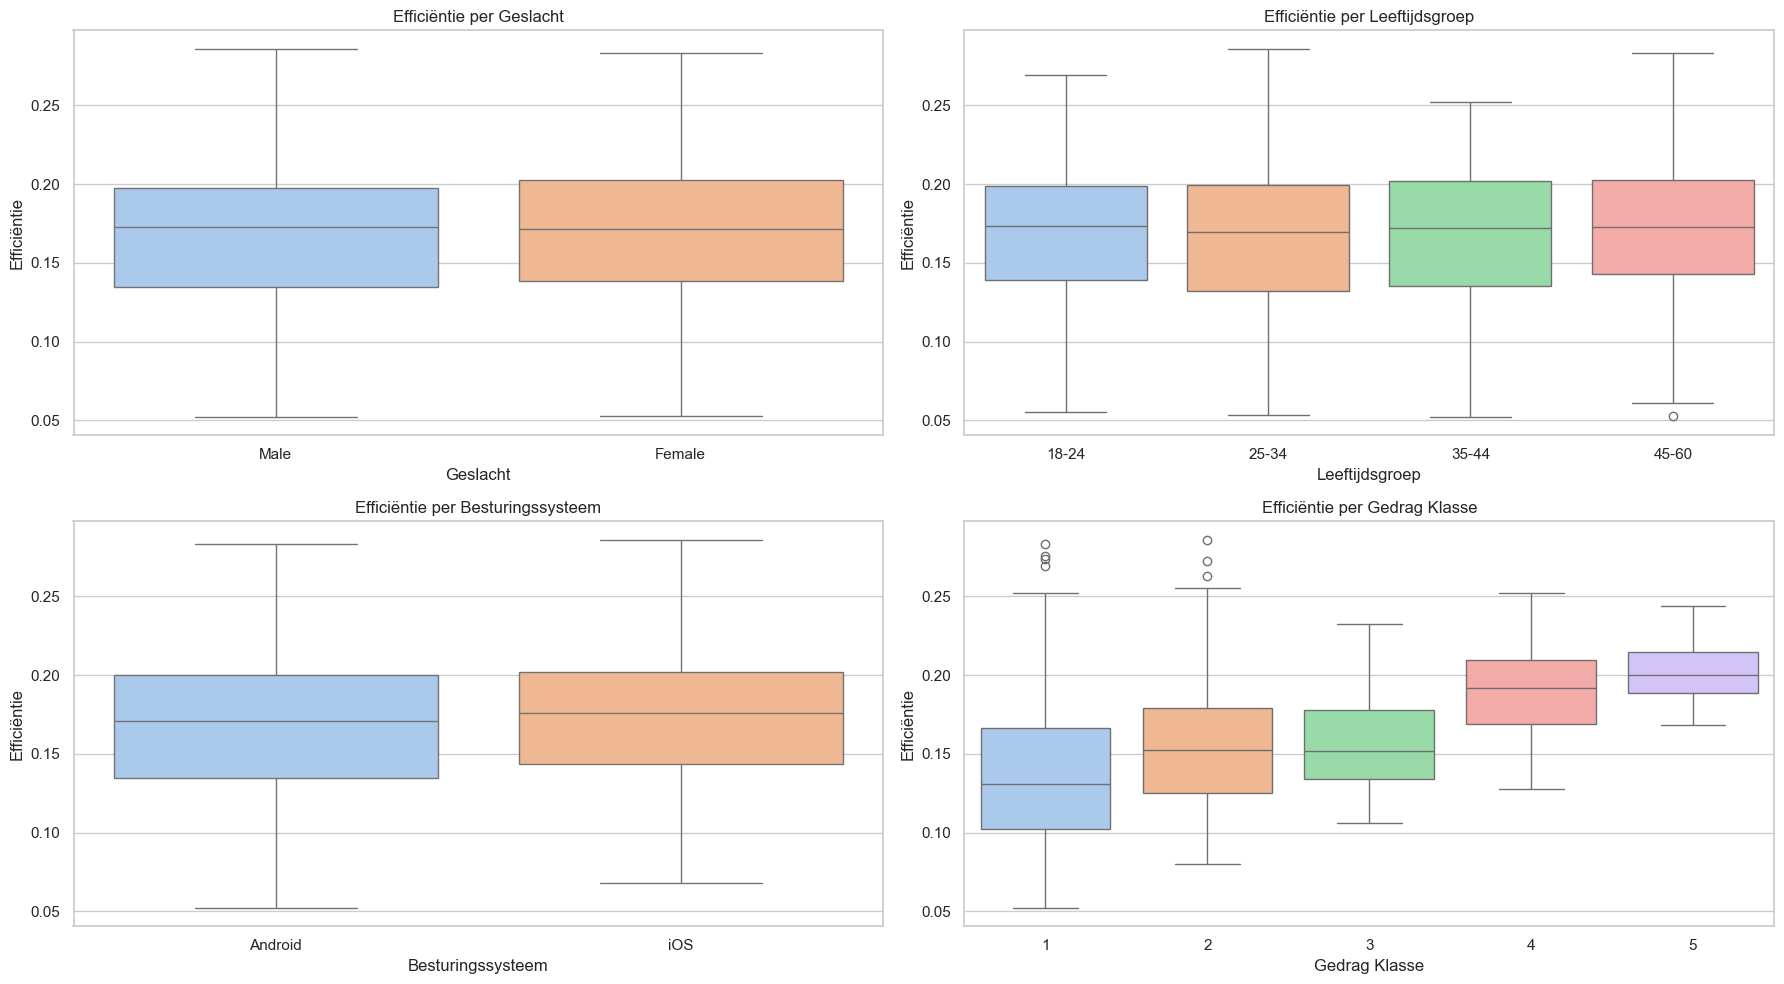

In [37]:
warnings.filterwarnings("ignore", category=FutureWarning)

fig, axes = plt.subplots(2, 2, figsize=(18, 10)) 

# Grafik 1: Gender
sns.boxplot(
    x='gender',
    y='efficiëntie',
    hue='gender',
    data=df,
    palette='pastel',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Efficiëntie per Geslacht')
axes[0, 0].set_xlabel('Geslacht')
axes[0, 0].set_ylabel('Efficiëntie')
if axes[0, 0].get_legend() is not None:
    axes[0, 0].get_legend().remove()

# Grafik 2: Leeftijdsgroep
sns.boxplot(
    x='leeftijdsgroep',
    y='efficiëntie',
    hue='leeftijdsgroep',
    data=df,
    palette='pastel',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Efficiëntie per Leeftijdsgroep')
axes[0, 1].set_xlabel('Leeftijdsgroep')
axes[0, 1].set_ylabel('Efficiëntie')
if axes[0, 1].get_legend() is not None:
    axes[0, 1].get_legend().remove()

# Grafik 3: Besturingssysteem
sns.boxplot(
    x='operating_system',
    y='efficiëntie',
    hue='operating_system',
    data=df,
    palette='pastel',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Efficiëntie per Besturingssysteem')
axes[1, 0].set_xlabel('Besturingssysteem')
axes[1, 0].set_ylabel('Efficiëntie')
if axes[1, 0].get_legend() is not None:
    axes[1, 0].get_legend().remove()

# Grafik 4: Gedrag Klasse
sns.boxplot(
    x='user_behavior_class',
    y='efficiëntie',
    hue='user_behavior_class',
    data=df,
    palette='pastel',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Efficiëntie per Gedrag Klasse')
axes[1, 1].set_xlabel('Gedrag Klasse')
axes[1, 1].set_ylabel('Efficiëntie')
if axes[1, 1].get_legend() is not None:
    axes[1, 1].get_legend().remove()

plt.tight_layout()
plt.show()




## Resultaten:

We kunnen nu de efficiëntie van verschillende gebruikersgroepen analyseren. Als bepaalde groepen een hogere efficiëntie vertonen, kunnen we deze groepen als "power users" beschouwen.

Bijv. leeftijdsgroepen kunnen we vergelijken, waar jongere gebruikers mogelijk meer batterij verbruiken voor app-gebruik, terwijl oudere gebruikers mogelijk efficiënter zijn.

We kunnen ook geslachtsverschillen onderzoeken en kijken of er een verschil is in efficiëntie tussen mannen en vrouwen.

Besturingssystemen (Android vs iOS) kunnen ook worden vergeleken om te zien welk platform efficiënter is.

### Analyse en opmerkingen:

Na het visualiseren van de resultaten kunnen we enkele belangrijke inzichten trekken:

De power users kunnen worden geïdentificeerd op basis van de efficiëntie, wat nuttig is voor toepassingen zoals app-optimalisatie en batterijbeheer.

We kunnen strategieën ontwikkelen voor energiebeheer en app-optimalisatie, gebaseerd op de efficiëncy scores van de gebruikers.

### Vergelijkbaarheid van de mediaan- Geslacht en EffitientieScor:

De mediaan van zowel mannen als vrouwen ligt ongeveer op hetzelfde punt. Dit geeft aan dat geslacht geen opvallend verschil maakt in de efficiëntie van het gebruik.

De gelijkenis in de mediaan suggereert dat beide geslachten vergelijkbaar gedrag vertonen als het gaat om de efficiëntie van hun apparaatgebruik.

Kleine Verschil: IQR van vrouwen is hoger:

Het interkwartielbereik (IQR) van vrouwen is iets groter, wat betekent dat er wat meer variabiliteit is in hun efficiëntie. De efficiëntie van vrouwen vertoont mogelijk meer spreiding, terwijl de efficiëntie van mannen minder variabel is en meer geconcentreerd lijkt.

Dit kan suggereren dat vrouwen verschillende gebruikspatronen of gebruiksscenario's kunnen hebben bij het gebruik van hun apparaten, maar in het algemeen heeft geslacht slechts een kleine invloed op de efficiëntie.

Kleine Verschil Tussen Mannen en Vrouwen:

Geslacht heeft over het algemeen geen significante invloed op de efficiëntie van het gebruik. Er lijkt een klein verschil te zijn waarbij vrouwen iets efficiënter zijn dan mannen, maar dit verschil is waarschijnlijk niet praktisch relevant.

Dit betekent dat de efficiëntie van zowel mannen als vrouwen niet veel van elkaar verschilt, hoewel vrouwen misschien iets efficiënter zijn in het gebruik van hun apparaten.

Conclusie:

Geslacht heeft een kleine invloed op de efficiëntie, maar het effect is minimaal. Vrouwen hebben iets hogere efficiëntiewaarden, maar dit verschil is waarschijnlijk niet significant.

De resultaten suggereren dat geslacht geen grote impact heeft op de efficiëntie van apparaatgebruik, maar het is nog steeds mogelijk om verschillende gebruikspatronen te onderzoeken die de efficiëntie kunnen beïnvloeden.

### Vergelijkbaarheid van de mediaan- Leeftijdsgroepen en EffitientieScor:

De mediaan van de efficiëntie in de verschillende leeftijdsgroepen is zeer vergelijkbaar. Dit geeft aan dat leeftijd geen significante invloed heeft op de efficiëntie van het gebruik van mobiele apparaten. De mediaan ligt in de buurt van dezelfde waarde voor de meeste groepen.

Outlier in de leeftijdsgroep 45-60:

In de leeftijdsgroep 45-60 is er één onderuitbijter (outlier) aan de onderkant, wat betekent dat er één of enkele gebruikers zijn die aanzienlijk minder efficiënt zijn dan de rest van de groep.

Deze outlier kan te maken hebben met bijzondere gebruikspatronen van sommige individuen in deze leeftijdsgroep, of mogelijk een fout in de gegevens.

### Vergelijking van de interkwartielbereiken (IQR):

De bovenste en onderste kwartielen voor alle leeftijdsgroepen zijn bijna gelijk voor de meeste groepen, wat betekent dat de variabiliteit in efficiëntie binnen de verschillende leeftijdsgroepen vrij consistent is.

De 25-34 en 35-44 leeftijdsgroepen vertonen een vrijwel gelijke spreiding van de efficiëntie, wat suggereert dat de gebruikers in deze leeftijdsgroepen op vergelijkbare manieren omgaan met hun appgebruik en batterijverbruik.

De 18-24 en 45-60 leeftijdsgroepen hebben echter een hogere onderste grens van hun interkwartielbereik, wat aangeeft dat deze groepen efficiënter zijn dan de andere leeftijdsgroepen, of dat de variabiliteit in hun efficiëntie minder is.

### Conclusie:
Leeftijd heeft weinig invloed op de efficiëntie, maar er zijn enkele subtiele verschillen tussen de leeftijdsgroepen.

De outlier in de 45-60 leeftijdsgroep kan verder onderzocht worden, aangezien het een indicatie kan zijn van afwijkend gebruiksgedrag in deze groep.

Over het algemeen lijkt de efficiëntie in de leeftijdsgroepen relatief vergelijkbaar, maar de spreiding is iets groter in de jongere en oudere leeftijdsgroepen (18-24 en 45-60), terwijl de middelste leeftijdsgroepen (25-34 en 35-44) een constante efficiëntie vertonen.

### Vergelijking van iOS met Android besturingssystemen en EffitientieScor:

De boxplot voor iOS toont een dichter box in vergelijking met andere besturingssystemen, wat suggereert dat de variabiliteit in efficiëntie onder iOS-gebruikers lager is. Dit betekent dat iOS-gebruikers in het algemeen meer consistente efficiëntie vertonen in hun appgebruik en batterijverbruik.

### Mediaan voor iOS-gebruikers:

De mediaan van iOS-gebruikers is licht hoger dan de andere besturingssystemen. Dit betekent dat de meeste iOS-gebruikers relatief efficiënter zijn in hun gebruik van mobiele apparaten, aangezien hun appgebruik in verhouding tot batterijverbruik iets beter is dan bij andere besturingssystemen.

### Interpretatie:

Hoewel de mediaan van iOS-gebruikers slechts een beetje hoger is, betekent de striktere spreiding dat iOS-gebruikers in het algemeen minder variëren in hun efficiëntie. Dit kan wijzen op het feit dat iOS-gebruikers mogelijk meer geoptimaliseerde applicaties en gebruikspatronen hebben, wat kan bijdragen aan een efficiënter gebruik van het apparaat.

### Conclusie:
iOS-gebruikers vertonen over het algemeen betere efficiëntie dan gebruikers van andere besturingssystemen, met minder variabiliteit en een iets hogere mediaan. Dit kan het resultaat zijn van betere optimalisatie van apps en besturingssysteem bij iOS, wat leidt tot een consistenter energieverbruik.










## De analyse per gedrag klasse toont de efficiëntie van gebruikers in verschillende categorieën:

Gedrag Klasse 1:

De breedste box met de laagste ondergrens, wat wijst op grote variatie in het gebruik. Gebruikers in deze klasse hebben zowel zeer efficiënte als zeer inefficiënte gebruikspatronen.

Gedrag Klasse 2:

De box is wat smaller en de ondergrens ligt hoger, wat duidt op meer consistentie en gemiddelde efficiëntie in app-gebruik.

Gedrag Klasse 3:

Deze box is nog smaller, met een hogere ondergrens, wat wijst op betere efficiëntie en meer geoptimaliseerd gebruik van apps.

Gedrag Klasse 4:

De smalste box, met een hogere positie, duidt op zeer efficiënte gebruikers die een optimale balans vinden tussen app-gebruik en batterijverbruik.

Gedrag Klasse 5:

Gebruikers in deze klasse zijn de meest efficiënte. De box is zeer smal en hoog, wat wijst op uitstekende energie-efficiëntie en geoptimaliseerd gebruik van apps.

Conclusie:
Gedrag Klasse 1 heeft de meeste variatie en moet verder geoptimaliseerd worden voor energieverbruik.

Gedrag Klasse 5 toont de meest efficiënte gebruikers, die het beste gebruik maken van batterij en apps.

Gedrag Klasse 3 en 4 tonen gemiddelde efficiëntie en kunnen profiteren van verdere optimalisatie.

Deze analyse is waardevol voor het identificeren van "power users" en kan helpen bij het verbeteren van energie-efficiëntie.

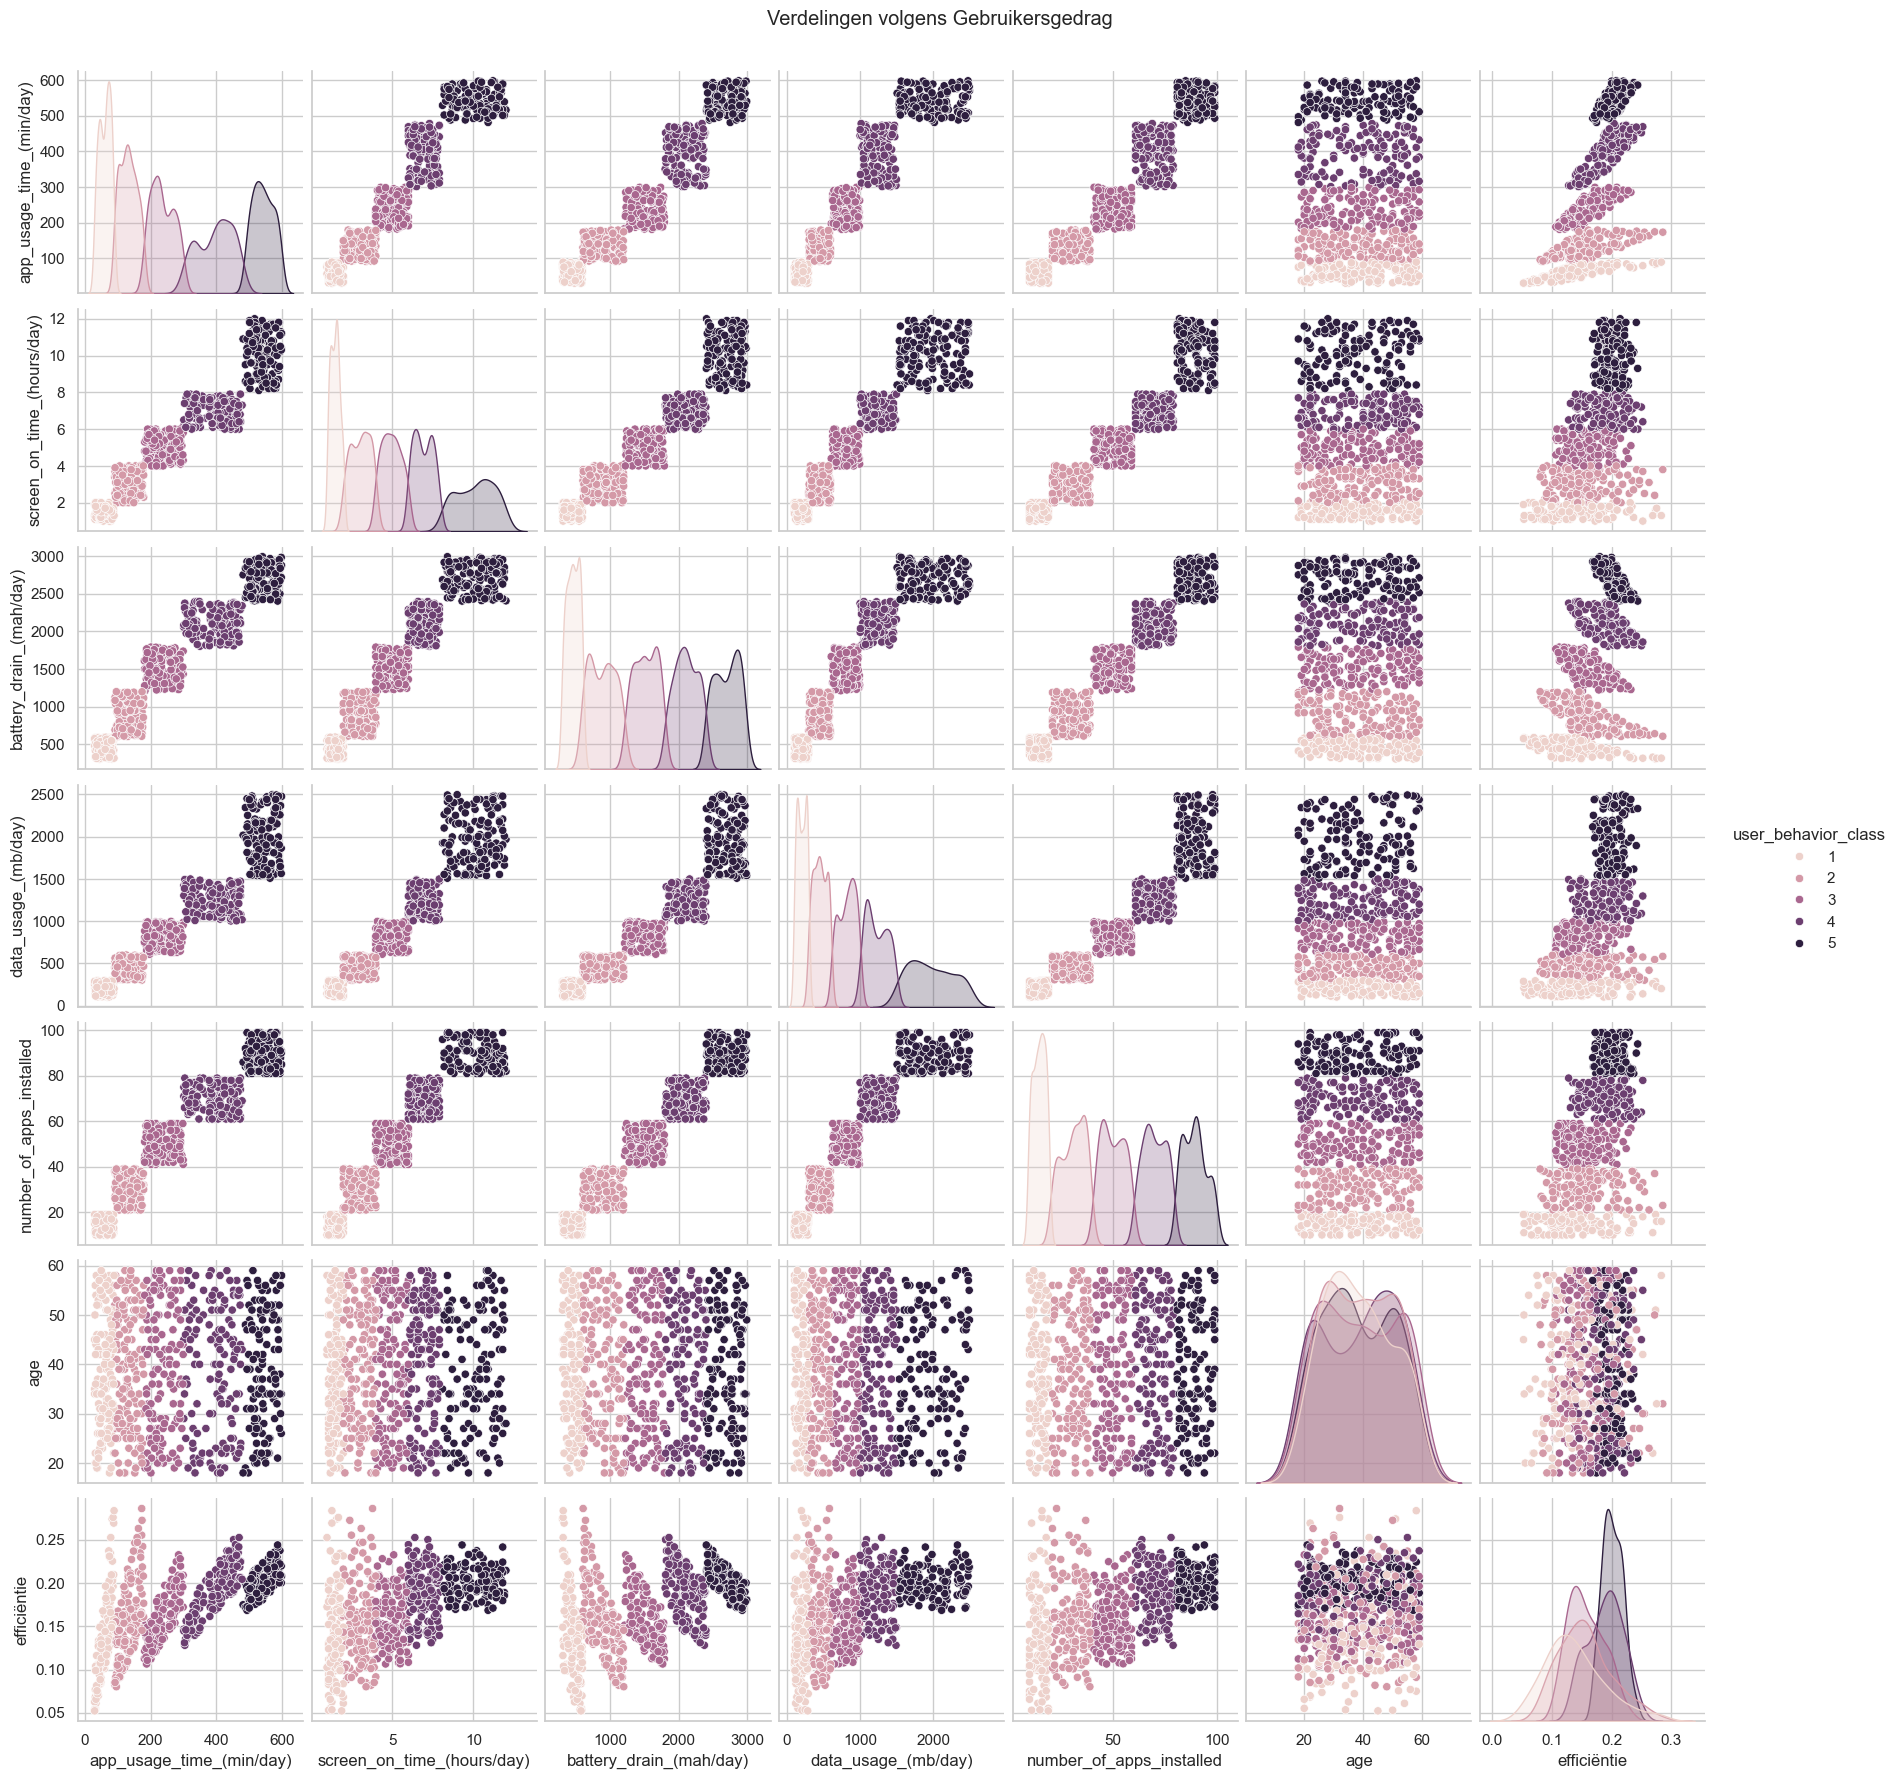

In [38]:
warnings.filterwarnings("ignore", category=FutureWarning)

numeric_cols = [
    'app_usage_time_(min/day)',      
    'screen_on_time_(hours/day)',    
    'battery_drain_(mah/day)',       
    'data_usage_(mb/day)',           
    'number_of_apps_installed',      
    'age',                           
    'efficiëntie'                    
]

sns.pairplot(df, hue='user_behavior_class', vars=numeric_cols)
plt.suptitle("Verdelingen volgens Gebruikersgedrag", y=1.02)
plt.show()


## Correlatieanalyse:

Correlatieanalyse is een techniek om de relatie tussen verschillende variabelen te meten. Deze analyse helpt ons te begrijpen hoe variabelen elkaar beïnvloeden. Bijvoorbeeld, we kunnen de correlatie berekenen om te zien of er een sterke relatie bestaat tussen de gebruikstijd van apps en het batterijverbruik.

Correlatiecoëfficiënt:

De correlatiecoëfficiënt kan een waarde hebben tussen -1 en 1.

1: Volledige positieve correlatie (de variabelen bewegen volledig parallel).

-1: Volledige negatieve correlatie (de variabelen bewegen in tegenovergestelde richting).

0: Geen relatie (er is geen verband tussen de variabelen).

Heatmap (Warmtekaart):

De heatmap visualiseert elke relatie in de correlatiematrix met kleuren. Dit maakt het snel duidelijk welke variabelen een sterke relatie met elkaar hebben.

Visualisatie van de Heatmap:

Om de correlatiematrix te visualiseren, gebruiken we de sns.heatmap() functie van de Seaborn bibliotheek. Dankzij deze visualisatie:

Kleuren vertegenwoordigen de correlatiecoëfficiënt.

Groene of rode kleuren geven sterke relaties aan.

Witte kleuren geven aan dat er geen relatie is tussen de variabelen.

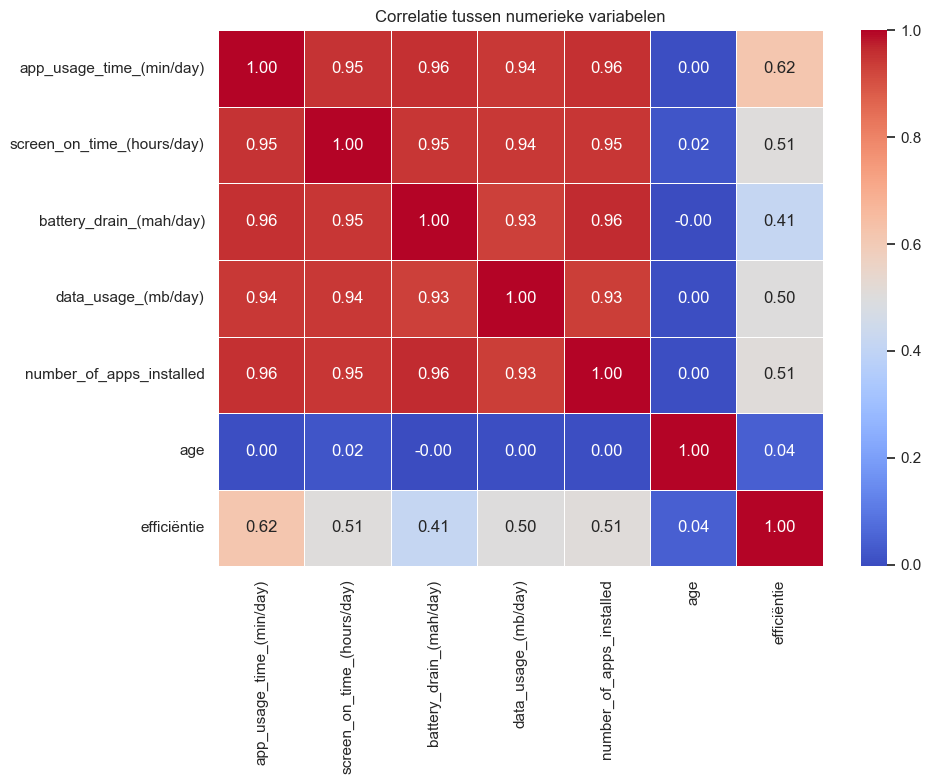

In [40]:
numerieke_data = [ 
    'app_usage_time_(min/day)',      
    'screen_on_time_(hours/day)',    
    'battery_drain_(mah/day)',       
    'data_usage_(mb/day)',           
    'number_of_apps_installed',      
    'age',                           
    'efficiëntie' 
    
]         

correlatie_df = df[numerieke_data]

correlatie_matrix = correlatie_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlatie_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlatie tussen numerieke variabelen')
plt.tight_layout()
plt.savefig('correlatie_heatmap.png', dpi=300)
plt.show()


Correlatiematrix toont sterkte van lineaire relaties tussen numerieke variabelen.

Leeftijd en numerieke variabelen: zwakke of geen correlatie

Uit de correlatiematrix blijkt dat leeftijd bijna geen lineaire relatie heeft met andere numerieke variabelen zoals:

App Usage Time (min/day) Screen On Time (hours/day) Battery Drain (mAh/day) Number of Apps Installed Data Usage (MB/day)

Bijvoorbeeld: Leeftijd ↔ Battery Drain: -0.00 Leeftijd ↔ Screen on Time: ~0.02 of iets negatiefs

Wat betekent dit? -- Geen of zeer zwakke correlatie Er is geen lineair verband tussen leeftijd en deze gedragsvariabelen.

Bijvoorbeeld: Oudere gebruikers hoeven niet per se minder of meer apps te gebruiken dan jongere gebruikers – althans, niet op een manier die lineair meetbaar is.

-->> Belangrijk: Geen correlatie ≠ geen relatie. Er kan nog steeds een niet-lineaire of categorische relatie bestaan. Bijvoorbeeld: bepaalde leeftijdsgroepen (zoals 18–24) kunnen ander gedrag vertonen, wat je met groepsvergelijkingen kunt onderzoeken.

Efficiëntie wordt vooral beïnvloed door gedragingen zoals app-gebruikstijd, schermtijd, batterijverbruik en datagebruik. Gebruikers die meer apps gebruiken, meer data verbruiken en langer op het scherm kijken, vertonen doorgaans efficiënter gebruik van hun apparaat en batterij.

Leeftijd heeft weinig invloed op efficiëntie, wat betekent dat gebruikersgedrag een grotere rol speelt in energieverbruik en efficiëntie dan leeftijd.

De sterkste relaties worden gevonden tussen app-gebruikstijd en efficiëntie, wat suggereert dat gebruikers die intensiever apps gebruiken, beter in staat zijn om hun energieverbruik te optimaliseren.

Conclusie:

Gebruikers die hun app-gebruik, schermtijd en batterijverbruik optimaliseren, kunnen hun energie-efficiëntie aanzienlijk verbeteren. Het creëren van bewustzijn over deze gedragingen kan gebruikers helpen om hun apparaten efficiënter te gebruiken.

Gebruikersgedrag blijkt ook een belangrijke factor te zijn die de efficiëntie beïnvloedt, wat betekent dat de gewoonten van gebruikers direct verband houden met hun efficiëntie.

### Relatie tussen Schermtijd en Batterijverbruik per Geslacht

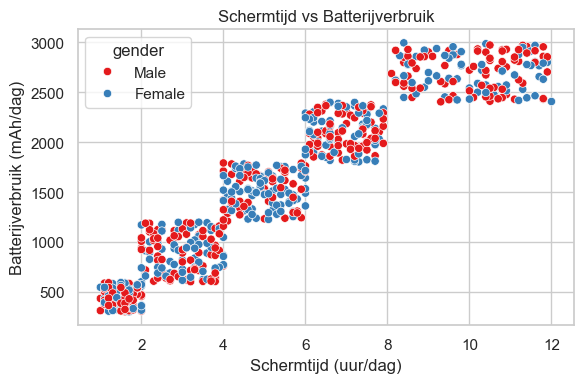

Pearson Correlatiecoëfficiënt: 0.95


In [43]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df,
    x='screen_on_time_(hours/day)',
    y='battery_drain_(mah/day)',
    hue='gender',  
    palette='Set1'
)
plt.title("Schermtijd vs Batterijverbruik")
plt.xlabel("Schermtijd (uur/dag)")
plt.ylabel("Batterijverbruik (mAh/dag)")
plt.tight_layout()
plt.savefig('schermtijd_battery_geslacht.png') 
plt.show()

correlation = df['screen_on_time_(hours/day)'].corr(df['battery_drain_(mah/day)'])
print(f"Pearson Correlatiecoëfficiënt: {correlation:.2f}")

### Relatie tussen schermtijd en batterijverbruik per toestelmodel (gesegmenteerd op geslacht)

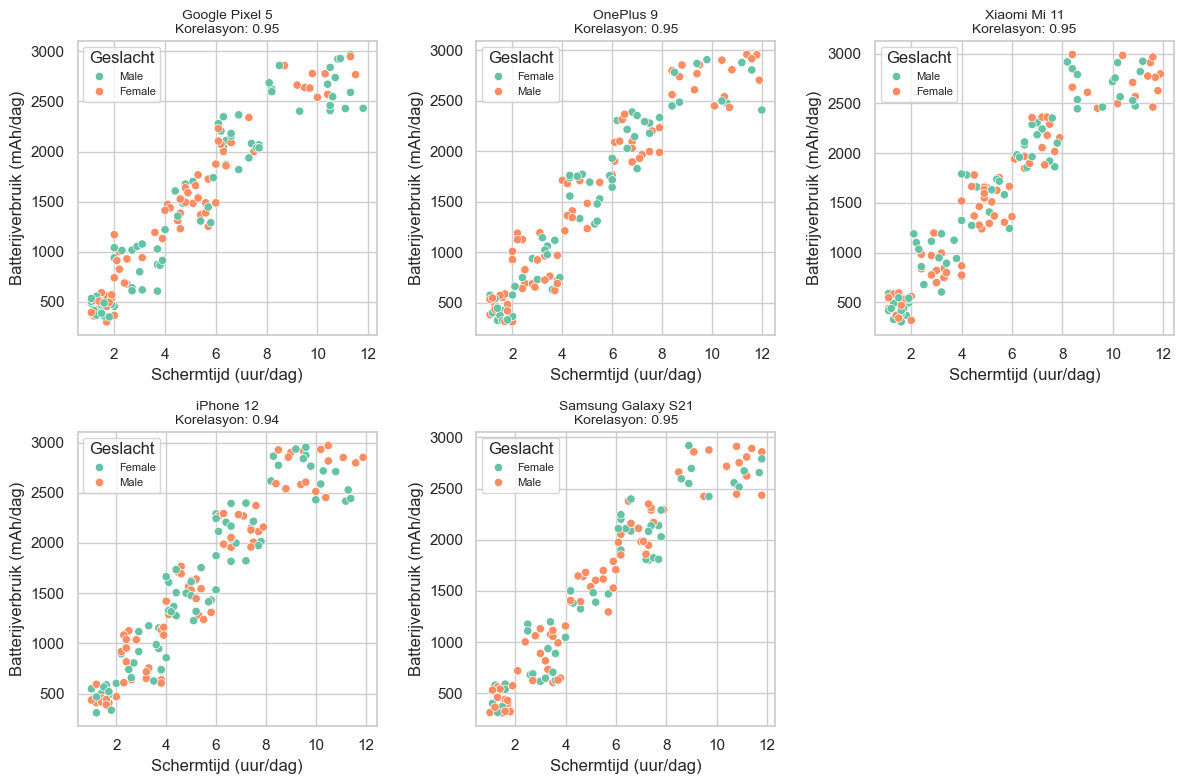

In [42]:

device_models = df["device_model"].unique()

n = len(device_models)
cols = 3
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
axes = axes.flatten()  

for i, model in enumerate(device_models):
    subset = df[df["device_model"] == model]
    
    
    corr_value = subset['screen_on_time_(hours/day)'].corr(subset['battery_drain_(mah/day)'])
    
    # Scatter plot
    sns.scatterplot(
        data=subset,
        x='screen_on_time_(hours/day)',
        y='battery_drain_(mah/day)',
        hue='gender',
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f"{model}\nKorelasyon: {corr_value:.2f}", fontsize=10)
    axes[i].set_xlabel("Schermtijd (uur/dag)")
    axes[i].set_ylabel("Batterijverbruik (mAh/dag)")
    axes[i].legend(title="Geslacht", loc='upper left', fontsize=8)


if len(device_models) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Deze visualisatie toont de relatie tussen schermtijd (in uren per dag) en batterijverbruik (in mAh per dag) voor elk afzonderlijk toestelmodel. Elk punt vertegenwoordigt een gebruiker, waarbij de kleur het geslacht aanduidt. Boven elke grafiek wordt de Pearson-correlatiecoëfficiënt weergegeven, die de sterkte en richting van het verband tussen de twee variabelen aangeeft.

Pearson Correlatiecoëfficiënt: 0.95

Deze waarde duidt op een zeer sterke positieve correlatie tussen schermtijd en batterijverbruik. Dit betekent dat gebruikers met een langere schermtijd vrijwel altijd ook een hoger batterijverbruik hebben.

In dit geval suggereert een waarde van 0.95 dat de relatie tussen deze twee variabelen bijna lineair is: naarmate de tijd dat het scherm aanstaat toeneemt, neemt ook het energieverbruik aanzienlijk toe.

Voor iPhone:

De Pearson-correlatie voor iPhone is 0.94, wat nog steeds wijst op een sterke positieve correlatie, maar iets zwakker dan de algemene dataset. Dit zou kunnen betekenen dat iPhone-gebruikers een meer geoptimaliseerd batterijverbruik hebben, of dat andere factoren (zoals energiebesparende functies) meer invloed hebben op de batterijduur.

Observaties:

De correlatie is bijzonder hoog, wat aangeeft dat het scherm gebruik een dominante factor is in het verbruik van de batterij.

Er kunnen ook verschillen zijn op basis van geslacht of toestelmodel, maar de algemene trend blijft sterk positief.

Conclusie: De zeer sterke correlatie tussen schermtijd en batterijverbruik suggereert dat toesteloptimalisatie gericht op schermbeheersing en energiebesparing aanzienlijke verbeteringen in batterijduur kan opleveren. Fabrikanten kunnen deze inzichten gebruiken om de efficiëntie van hun toestellen verder te verbeteren op basis van gebruikersgedrag.

